# 🗺️ Notebook 04 — Analyse Stratégique LFB

## Objectif
Après avoir démontré que la prédiction ponctuelle du temps de réponse a des limites intrinsèques (intervalle de prédiction ~4 min, non exploitable en centre d'appel opérationnel), ce notebook pivote vers un **outil d'analyse stratégique** destiné aux décideurs de la LFB.

## Livrables
1. **Cartographie des inégalités territoriales** — quelles zones sont sous-desservies ?
2. **Analyse temporelle** — évolution 2009-2026, impact des fermetures 2014, du COVID
3. **Segmentation par type d'incident** — patterns Fire vs Special Service vs False Alarm
4. **Identification des zones prioritaires** pour ouverture/renforcement de casernes

## Insights recherchés
- Amplitude géographique des temps de réponse
- Facteurs structurels vs conjoncturels
- Recommandations chiffrées pour la LFB

In [1]:
"""
=== SETUP NOTEBOOK 04 — Analyse stratégique ===
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Style visuel
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Chemins
project_root  = Path('..').resolve()
PROCESSED_DIR = project_root / 'data' / 'processed'
REPORTS_DIR   = project_root / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# Rechargement silver v2
print("📂 Chargement silver v2...")
start = time.time()
df = pd.read_parquet(PROCESSED_DIR / 'lfb_features_v2.parquet')
print(f"✅ Chargé en {time.time()-start:.1f}s — {df.shape}")

# Ajout d'une colonne 'decade' pour analyses temporelles
df['decade'] = (df['year'] // 5) * 5  # bucketing 5 ans

# Récap
print(f"\n📊 Contexte du dataset")
print(f"   Période         : {df['CalYear'].min()} → {df['CalYear'].max()}")
print(f"   Nombre incidents: {len(df):,}")
print(f"   Boroughs        : {df['borough'].nunique()}")
print(f"   Postcodes       : {df['Postcode_district'].nunique()}")

📂 Chargement silver v2...
✅ Chargé en 1.1s — (1816534, 57)

📊 Contexte du dataset
   Période         : 2009 → 2026
   Nombre incidents: 1,816,534
   Boroughs        : 33
   Postcodes       : 329


=== INÉGALITÉS TERRITORIALES — 33 boroughs ===

Amplitude médiane : 1.82 min
Ratio            : 1.43×

Le borough le PLUS RAPIDE (KENSINGTON AND CHELSEA) est 1.82 min plus rapide
que le PLUS LENT (HILLINGDON).



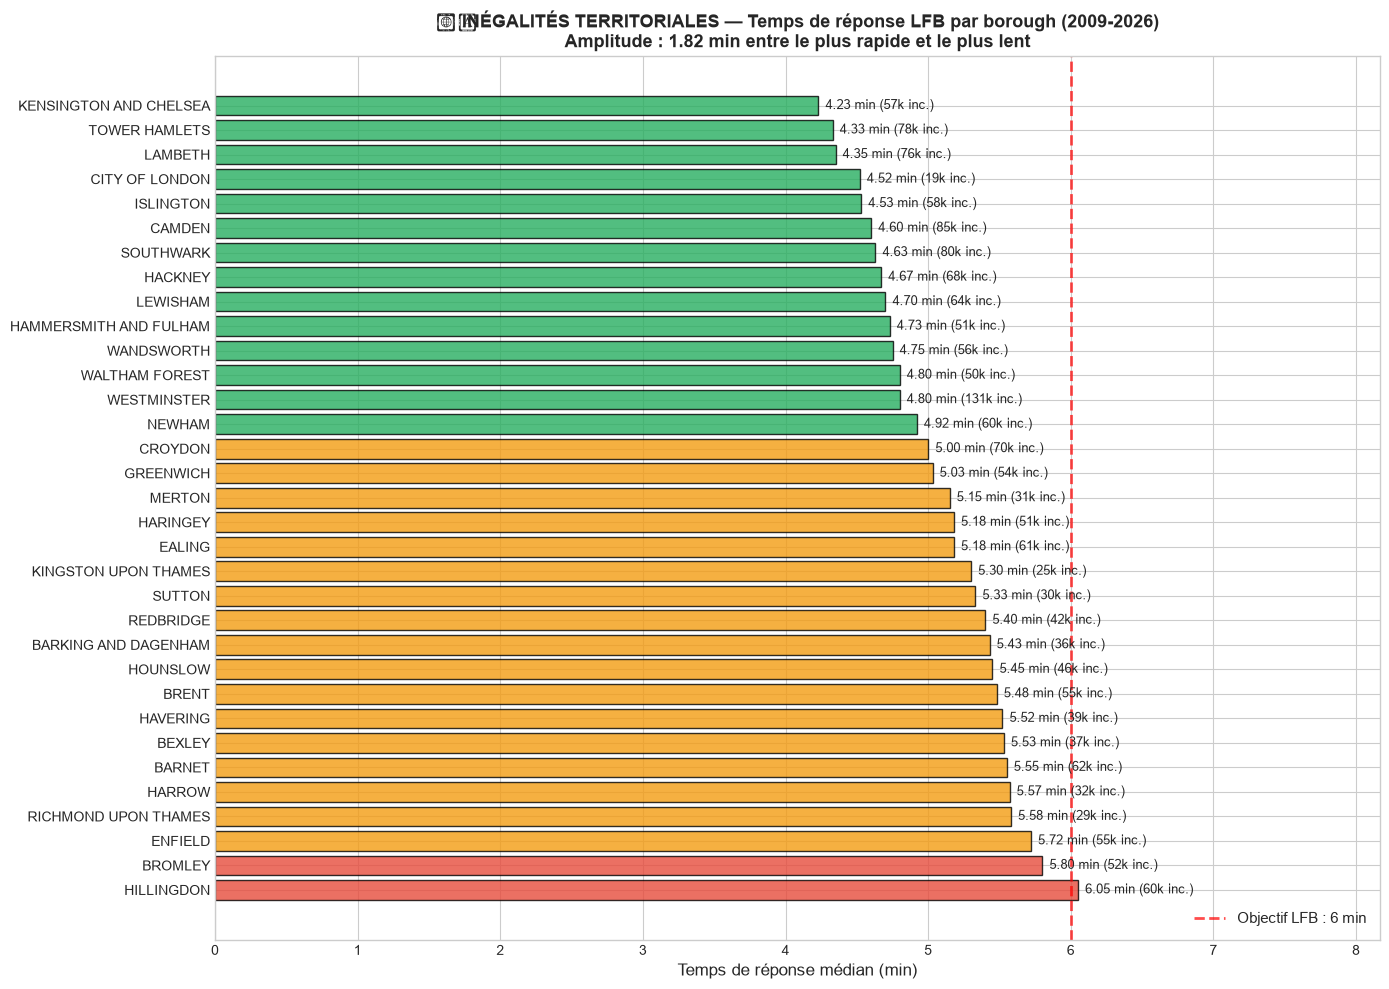


=== TOP 5 BOROUGHS LES PLUS RAPIDES ===
                        incidents_total  mean_response  median_response  p90_response  std_response  pct_above_6min
borough                                                                                                            
KENSINGTON AND CHELSEA            57592           4.55             4.23          6.83          1.93            16.2
TOWER HAMLETS                     78284           4.69             4.33          6.92          1.97            17.4
LAMBETH                           76582           4.67             4.35          6.93          1.95            18.1
CITY OF LONDON                    19261           4.85             4.52          6.93          1.89            18.2
ISLINGTON                         58362           4.83             4.53          6.98          1.87            18.7

=== TOP 5 BOROUGHS LES PLUS LENTS ===
                      incidents_total  mean_response  median_response  p90_response  std_response  pct_above

In [2]:
"""
=== ANALYSE #1 : INÉGALITÉS TERRITORIALES ===
Objectif : quantifier les disparités entre boroughs.
"""

# Stats par borough
borough_stats = df.groupby('borough').agg(
    incidents_total=('AttendanceTimeMinutes', 'count'),
    mean_response=('AttendanceTimeMinutes', 'mean'),
    median_response=('AttendanceTimeMinutes', 'median'),
    p90_response=('AttendanceTimeMinutes', lambda x: x.quantile(0.9)),
    std_response=('AttendanceTimeMinutes', 'std')
).round(2)

borough_stats['pct_above_6min'] = df.groupby('borough')['AttendanceTimeMinutes'].apply(lambda x: (x > 6).mean() * 100).round(1)
borough_stats = borough_stats.sort_values('median_response')

print("=== INÉGALITÉS TERRITORIALES — 33 boroughs ===\n")
print(f"Amplitude médiane : {borough_stats['median_response'].max() - borough_stats['median_response'].min():.2f} min")
print(f"Ratio            : {borough_stats['median_response'].max() / borough_stats['median_response'].min():.2f}×")
print(f"\nLe borough le PLUS RAPIDE ({borough_stats.index[0]}) est {(borough_stats.iloc[-1]['median_response'] - borough_stats.iloc[0]['median_response']):.2f} min plus rapide")
print(f"que le PLUS LENT ({borough_stats.index[-1]}).\n")

# Visualisation double barres
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#27ae60' if x < 5 else '#f39c12' if x < 5.8 else '#e74c3c' 
          for x in borough_stats['median_response']]

y_pos = np.arange(len(borough_stats))
bars = ax.barh(y_pos, borough_stats['median_response'], color=colors, edgecolor='black', alpha=0.8)

# Ligne de référence objectif LFB (6 min)
ax.axvline(6, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Objectif LFB : 6 min')

# Annotations sur les barres
for i, (idx, row) in enumerate(borough_stats.iterrows()):
    ax.text(row['median_response'] + 0.05, i, f"{row['median_response']:.2f} min ({int(row['incidents_total']/1000)}k inc.)",
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(borough_stats.index, fontsize=10)
ax.set_xlabel('Temps de réponse médian (min)', fontsize=12)
ax.set_title('🗺️ INÉGALITÉS TERRITORIALES — Temps de réponse LFB par borough (2009-2026)\n' +
             f"Amplitude : {borough_stats['median_response'].max() - borough_stats['median_response'].min():.2f} min entre le plus rapide et le plus lent",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, borough_stats['median_response'].max() * 1.35)
ax.invert_yaxis()  # meilleurs en haut

plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_inequalities_by_borough.png', dpi=100, bbox_inches='tight')
plt.show()

# Tableau détaillé
print(f"\n=== TOP 5 BOROUGHS LES PLUS RAPIDES ===")
print(borough_stats.head(5))

print(f"\n=== TOP 5 BOROUGHS LES PLUS LENTS ===")
print(borough_stats.tail(5))

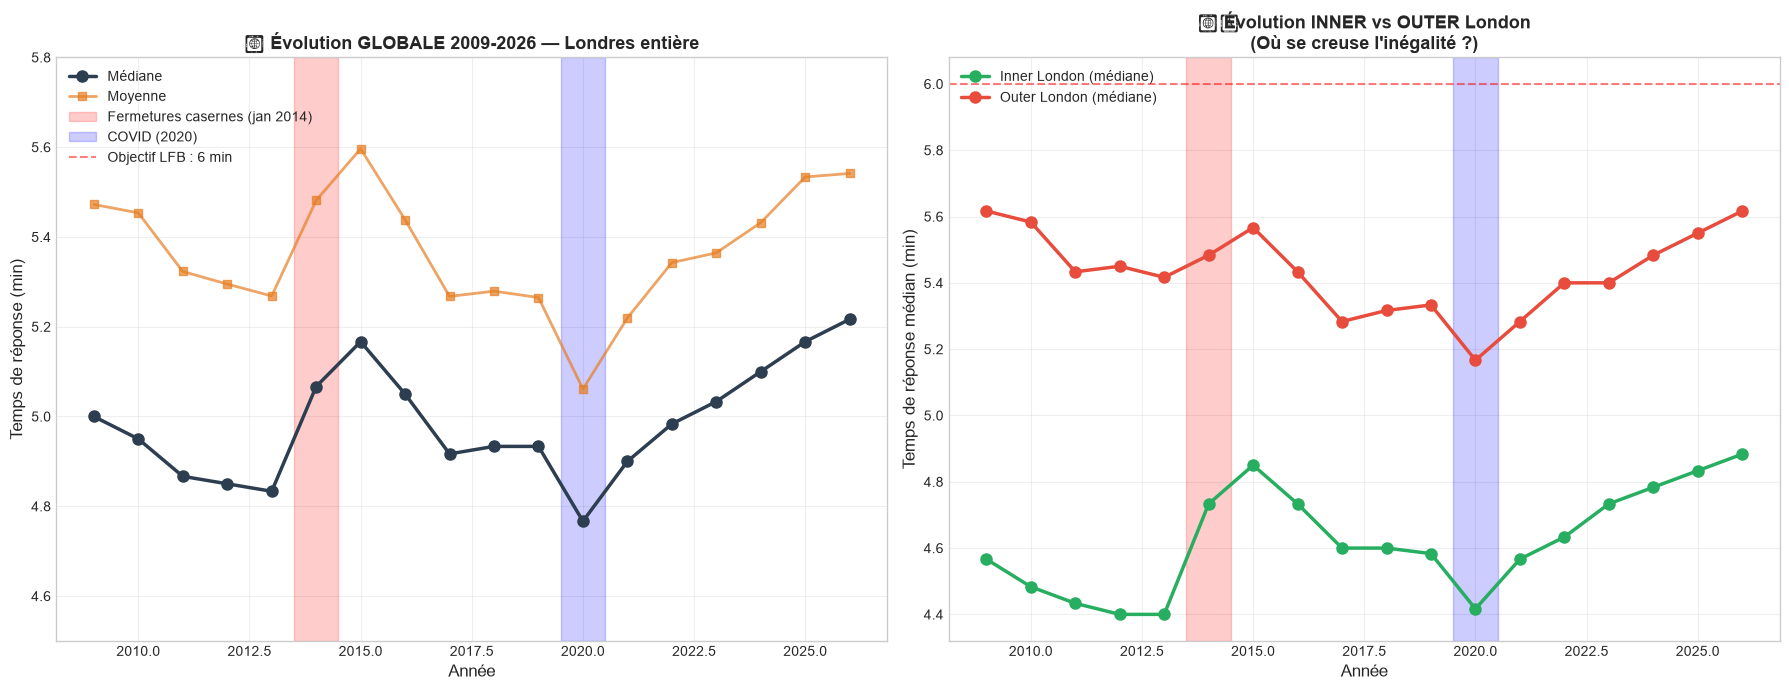

=== CHIFFRES CLÉS ÉVOLUTION TEMPORELLE ===

📊 Médiane 2009 : 5.00 min
📊 Médiane 2014 (fermetures) : 5.07 min (+1.3% vs 2009)
📊 Médiane 2020 (COVID) : 4.77 min (-4.7% vs 2009)
📊 Médiane 2025 : 5.17 min (+8.4% vs 2020, +3.3% vs 2009)

=== INNER vs OUTER — évolution 2019 → 2025 ===
  Inner London   : 4.58 min → 4.83 min (+5.5%)
  Outer London   : 5.33 min → 5.55 min (+4.1%)


In [4]:
"""
=== ANALYSE #2 : ÉVOLUTION TEMPORELLE 2009-2026 ===
Objectif : quantifier le drift COVID + l'impact des fermetures de casernes 2014.
"""

# Classification inner/outer London
inner_london = ['KENSINGTON AND CHELSEA', 'TOWER HAMLETS', 'LAMBETH', 'CITY OF LONDON',
                'ISLINGTON', 'CAMDEN', 'SOUTHWARK', 'HACKNEY', 'LEWISHAM',
                'HAMMERSMITH AND FULHAM', 'WANDSWORTH', 'WALTHAM FOREST', 'WESTMINSTER',
                'NEWHAM']
df['zone'] = df['borough'].apply(lambda b: 'Inner London' if b in inner_london else 'Outer London')

# Stats par année et zone
by_year_zone = df.groupby(['year', 'zone']).agg(
    median=('AttendanceTimeMinutes', 'median'),
    mean=('AttendanceTimeMinutes', 'mean'),
    count=('AttendanceTimeMinutes', 'count')
).reset_index()

by_year_global = df.groupby('year').agg(
    median=('AttendanceTimeMinutes', 'median'),
    mean=('AttendanceTimeMinutes', 'mean'),
    count=('AttendanceTimeMinutes', 'count')
).reset_index()

# Visualisation avec 2 panneaux
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panneau 1 : Évolution globale ---
ax1 = axes[0]
ax1.plot(by_year_global['year'], by_year_global['median'], marker='o', linewidth=2.5, 
         color='#2c3e50', label='Médiane', markersize=8)
ax1.plot(by_year_global['year'], by_year_global['mean'], marker='s', linewidth=2, 
         color='#e67e22', label='Moyenne', markersize=6, alpha=0.7)

# Annotations événements clés
ax1.axvspan(2013.5, 2014.5, alpha=0.2, color='red', label='Fermetures casernes (jan 2014)')
ax1.axvspan(2019.5, 2020.5, alpha=0.2, color='blue', label='COVID (2020)')
ax1.axhline(6, color='red', linestyle='--', alpha=0.5, label='Objectif LFB : 6 min')

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Temps de réponse (min)', fontsize=12)
ax1.set_title('📈 Évolution GLOBALE 2009-2026 — Londres entière',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(4.5, 5.8)

# --- Panneau 2 : Inner vs Outer London ---
ax2 = axes[1]

for zone, color in [('Inner London', '#27ae60'), ('Outer London', '#e74c3c')]:
    subset = by_year_zone[by_year_zone['zone'] == zone]
    ax2.plot(subset['year'], subset['median'], marker='o', linewidth=2.5, 
             color=color, label=f'{zone} (médiane)', markersize=8)

ax2.axvspan(2013.5, 2014.5, alpha=0.2, color='red')
ax2.axvspan(2019.5, 2020.5, alpha=0.2, color='blue')
ax2.axhline(6, color='red', linestyle='--', alpha=0.5)

ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Temps de réponse médian (min)', fontsize=12)
ax2.set_title('🗺️ Évolution INNER vs OUTER London\n' + 
              '(Où se creuse l\'inégalité ?)',
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / '02_temporal_evolution.png', dpi=100, bbox_inches='tight')
plt.show()

# Chiffres clés
print("=== CHIFFRES CLÉS ÉVOLUTION TEMPORELLE ===\n")
median_2009 = by_year_global[by_year_global['year'] == 2009]['median'].values[0]
median_2014 = by_year_global[by_year_global['year'] == 2014]['median'].values[0]
median_2020 = by_year_global[by_year_global['year'] == 2020]['median'].values[0]
median_2025 = by_year_global[by_year_global['year'] == 2025]['median'].values[0]

print(f"📊 Médiane 2009 : {median_2009:.2f} min")
print(f"📊 Médiane 2014 (fermetures) : {median_2014:.2f} min ({(median_2014/median_2009-1)*100:+.1f}% vs 2009)")
print(f"📊 Médiane 2020 (COVID) : {median_2020:.2f} min ({(median_2020/median_2009-1)*100:+.1f}% vs 2009)")
print(f"📊 Médiane 2025 : {median_2025:.2f} min ({(median_2025/median_2020-1)*100:+.1f}% vs 2020, {(median_2025/median_2009-1)*100:+.1f}% vs 2009)")

# Comparaison Inner/Outer sur 2019 vs 2025
print(f"\n=== INNER vs OUTER — évolution 2019 → 2025 ===")
for zone in ['Inner London', 'Outer London']:
    v_2019 = by_year_zone[(by_year_zone['year'] == 2019) & (by_year_zone['zone'] == zone)]['median'].values[0]
    v_2025 = by_year_zone[(by_year_zone['year'] == 2025) & (by_year_zone['zone'] == zone)]['median'].values[0]
    print(f"  {zone:15}: {v_2019:.2f} min → {v_2025:.2f} min ({(v_2025/v_2019-1)*100:+.1f}%)")

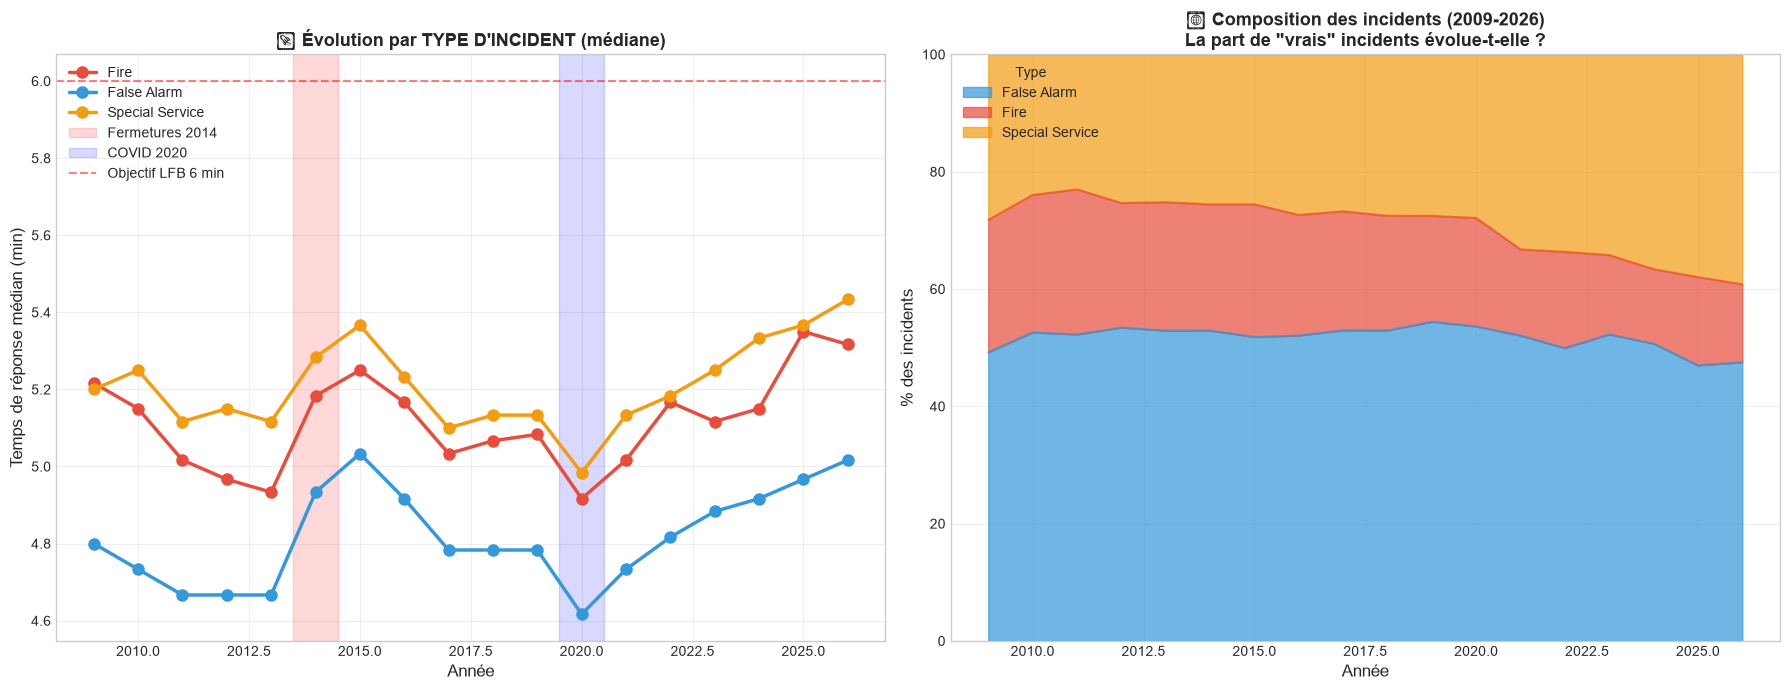

=== CHIFFRES CLÉS PAR TYPE D'INCIDENT ===

                 volume_total  part_pct  median  mean   p90  pct_above_6min
IncidentGroup                                                              
False Alarm            938670     51.67    4.82  5.17  7.70           26.38
Fire                   342618     18.86    5.12  5.53  8.32           32.45
Special Service        535241     29.46    5.22  5.62  8.48           34.40

=== Évolution PART DES FEUX ===
2010 : 23.4%
2025 : 15.0%
Δ    : -8.4 points

=== Évolution PART DES SPECIAL SERVICE ===
2010 : 24.0%
2025 : 38.0%
Δ    : +14.0 points


In [5]:
"""
=== ANALYSE #3 : PATTERNS PAR TYPE D'INCIDENT ===
Objectif : identifier si Fire, False Alarm, Special Service ont des dynamiques différentes.
"""

# Stats par type d'incident × année
by_type_year = df.groupby(['year', 'IncidentGroup']).agg(
    median=('AttendanceTimeMinutes', 'median'),
    mean=('AttendanceTimeMinutes', 'mean'),
    count=('AttendanceTimeMinutes', 'count')
).reset_index()

# Répartition volumétrique par année (pour voir si la composition change)
composition = df.groupby(['year', 'IncidentGroup']).size().unstack(fill_value=0)
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

# Fig
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panneau 1 : Évolution médiane par type ---
ax1 = axes[0]
colors_type = {'Fire': '#e74c3c', 'False Alarm': '#3498db', 'Special Service': '#f39c12'}
for inc_type, color in colors_type.items():
    subset = by_type_year[by_type_year['IncidentGroup'] == inc_type]
    ax1.plot(subset['year'], subset['median'], marker='o', linewidth=2.5,
             color=color, label=f'{inc_type}', markersize=8)

ax1.axvspan(2013.5, 2014.5, alpha=0.15, color='red', label='Fermetures 2014')
ax1.axvspan(2019.5, 2020.5, alpha=0.15, color='blue', label='COVID 2020')
ax1.axhline(6, color='red', linestyle='--', alpha=0.5, label='Objectif LFB 6 min')

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Temps de réponse médian (min)', fontsize=12)
ax1.set_title('🚨 Évolution par TYPE D\'INCIDENT (médiane)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Panneau 2 : Répartition volumétrique ---
ax2 = axes[1]
composition_pct.plot(kind='area', stacked=True, ax=ax2, alpha=0.7,
                     color=[colors_type[c] for c in composition_pct.columns])
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('% des incidents', fontsize=12)
ax2.set_title('📊 Composition des incidents (2009-2026)\n' + 
              'La part de "vrais" incidents évolue-t-elle ?', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10, title='Type')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / '03_by_incident_type.png', dpi=100, bbox_inches='tight')
plt.show()

# Chiffres clés
print("=== CHIFFRES CLÉS PAR TYPE D'INCIDENT ===\n")
print(df.groupby('IncidentGroup').agg(
    volume_total=('AttendanceTimeMinutes', 'count'),
    part_pct=('AttendanceTimeMinutes', lambda x: len(x) / len(df) * 100),
    median=('AttendanceTimeMinutes', 'median'),
    mean=('AttendanceTimeMinutes', 'mean'),
    p90=('AttendanceTimeMinutes', lambda x: x.quantile(0.9)),
    pct_above_6min=('AttendanceTimeMinutes', lambda x: (x > 6).mean() * 100)
).round(2))

# Évolution part de Fire
fire_2010 = composition_pct.loc[2010, 'Fire']
fire_2025 = composition_pct.loc[2025, 'Fire']
print(f"\n=== Évolution PART DES FEUX ===")
print(f"2010 : {fire_2010:.1f}%")
print(f"2025 : {fire_2025:.1f}%")
print(f"Δ    : {fire_2025 - fire_2010:+.1f} points")

# Pareil pour Special Service
ss_2010 = composition_pct.loc[2010, 'Special Service']
ss_2025 = composition_pct.loc[2025, 'Special Service']
print(f"\n=== Évolution PART DES SPECIAL SERVICE ===")
print(f"2010 : {ss_2010:.1f}%")
print(f"2025 : {ss_2025:.1f}%")
print(f"Δ    : {ss_2025 - ss_2010:+.1f} points")

=== TOP 10 ZONES PRIORITAIRES D'INVESTISSEMENT ===

                      n_incidents_recent  median_recent  pct_above_6min_recent  degradation_pct  score_priorite
borough                                                                                                        
HILLINGDON                         12346           6.08                  51.55              5.7            77.3
EALING                             13245           5.40                  39.83              7.9            73.2
RICHMOND UPON THAMES                5776           5.75                  44.86             10.9            69.4
BROMLEY                            10920           5.83                  46.92              5.3            68.3
LEWISHAM                           14065           4.98                  31.18             10.7            68.2
ENFIELD                            10935           5.73                  44.55              4.2            64.1
NEWHAM                             12330           5

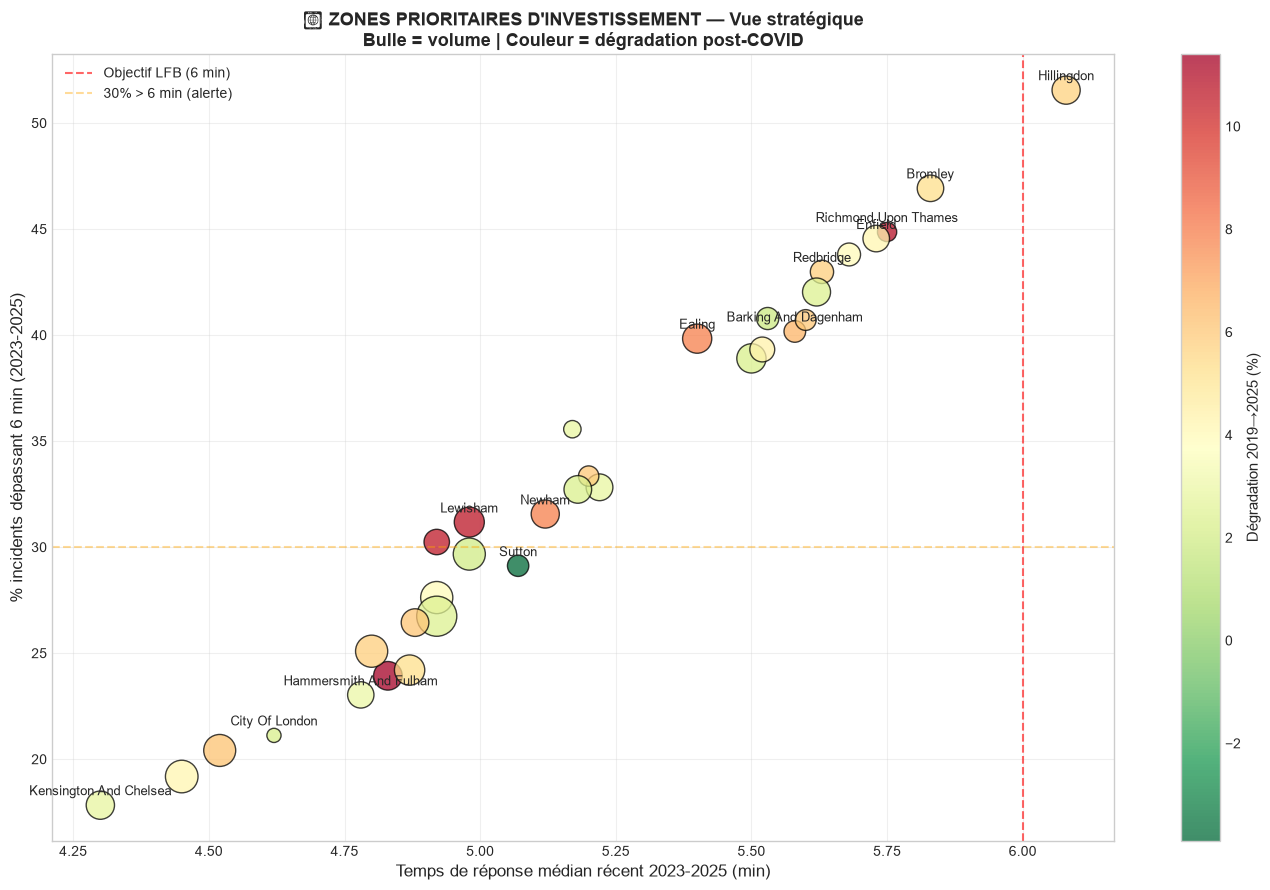

In [7]:
"""
=== ANALYSE #4 : ZONES PRIORITAIRES D'INVESTISSEMENT ===
Objectif : identifier les boroughs où LFB devrait renforcer sa présence.
Critère composite : temps médian × volume × dégradation récente.
"""

# Récent = 2023-2025 pour capturer l'état actuel
df_recent = df[df['year'].isin([2023, 2024, 2025])]

# Stats par borough (période récente + historique)
zones_priority = df.groupby('borough').agg(
    n_incidents_total=('AttendanceTimeMinutes', 'count'),
    median_hist=('AttendanceTimeMinutes', 'median')
).round(2)

recent_stats = df_recent.groupby('borough').agg(
    n_incidents_recent=('AttendanceTimeMinutes', 'count'),
    median_recent=('AttendanceTimeMinutes', 'median'),
    pct_above_6min_recent=('AttendanceTimeMinutes', lambda x: (x > 6).mean() * 100),
    p90_recent=('AttendanceTimeMinutes', lambda x: x.quantile(0.9))
).round(2)

zones_priority = zones_priority.join(recent_stats)

# Dégradation 2019 vs 2025 (drift post-COVID par borough)
median_2019 = df[df['year'] == 2019].groupby('borough')['AttendanceTimeMinutes'].median()
median_2025 = df[df['year'] == 2025].groupby('borough')['AttendanceTimeMinutes'].median()
zones_priority['degradation_pct'] = ((median_2025 / median_2019) - 1) * 100
zones_priority['degradation_pct'] = zones_priority['degradation_pct'].round(1)

# Score de priorité = combinaison pondérée
# On veut prioriser : (1) temps long récent (2) gros volume (3) forte dégradation
zones_priority['score_priorite'] = (
    zones_priority['median_recent'].rank(pct=True) * 40 +           # 40% : temps récent
    zones_priority['n_incidents_recent'].rank(pct=True) * 30 +      # 30% : volume
    zones_priority['degradation_pct'].rank(pct=True) * 30           # 30% : dégradation
).round(1)

zones_priority = zones_priority.sort_values('score_priorite', ascending=False)

print("=== TOP 10 ZONES PRIORITAIRES D'INVESTISSEMENT ===\n")
print(zones_priority[['n_incidents_recent', 'median_recent', 'pct_above_6min_recent',
                      'degradation_pct', 'score_priorite']].head(10))

print("\n=== BOTTOM 10 (déjà bien desservis) ===")
print(zones_priority[['n_incidents_recent', 'median_recent', 'pct_above_6min_recent',
                      'degradation_pct', 'score_priorite']].tail(10))

# Visualisation Bubble chart
fig, ax = plt.subplots(figsize=(14, 9))

# Bulle = volume ; couleur = dégradation ; axe X = médiane récente ; axe Y = % au-dessus 6min
scatter = ax.scatter(
    zones_priority['median_recent'],
    zones_priority['pct_above_6min_recent'],
    s=zones_priority['n_incidents_recent'] / 30,
    c=zones_priority['degradation_pct'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='black',
    linewidth=1
)

# Annotations
for borough, row in zones_priority.iterrows():
    if row['score_priorite'] >= 60 or row['score_priorite'] <= 30:
        ax.annotate(borough.title(), 
                   (row['median_recent'], row['pct_above_6min_recent']),
                   fontsize=9, ha='center', va='bottom',
                   xytext=(0, 5), textcoords='offset points')

# Ligne objectif LFB
ax.axvline(6, color='red', linestyle='--', alpha=0.6, label='Objectif LFB (6 min)')
ax.axhline(30, color='orange', linestyle='--', alpha=0.4, label='30% > 6 min (alerte)')

ax.set_xlabel('Temps de réponse médian récent 2023-2025 (min)', fontsize=12)
ax.set_ylabel('% incidents dépassant 6 min (2023-2025)', fontsize=12)
ax.set_title('🎯 ZONES PRIORITAIRES D\'INVESTISSEMENT — Vue stratégique\n' +
             'Bulle = volume | Couleur = dégradation post-COVID',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Dégradation 2019→2025 (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / '04_priority_zones.png', dpi=100, bbox_inches='tight')
plt.show()